# Brownian motion

Een van de bekendste voorbeelden van botsende deeltjes in de natuur is Brownian motion.
Fijn gemalen pollen in water lijken te dansen in willekeurige richting.
Dit komt doordat de pollen worden geraakt door watermoleculen die in alle richtingen bewegen.
Omdat de pollen veel zwaarder zijn dan watermoleculen, dus de beweging van de pollen is veel langzamer en minder "intens" dan die van de watermoleculen.
Dit proces van willekeurige beweging door botsingen met kleinere deeltjes wordt Brownian motion genoemd en kunnen we simuleren op basis van ons (premature) botsingsmodel.
Daarbij kunnen we ook gebruik maken van de zojuist geleerde manier van tracking van deeltjes, waarbij we een zowel het zware bolletjes als een enkel deeltje kunnen volgen.

Let op!
We bestuderen hier nog geen thermische effecten, deze opdrachten zijn met name bedoeld om beter te begrijpen hoe het botsingsmodel in elkaar zit.

```{warning}
In dit notebook zitten delen waar ruimte is om code toe te voegen, maar waarbij je denkt... waarom dan?
In een latere opdracht moet je terug naar die cell en de juiste code toevoegen.
```

In [136]:
import numpy as np
import matplotlib.pyplot as plt

In [137]:
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R, c):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  
        self.c = c

    # Het updaten van de positie, eventueel met zwaartekracht
    def update_position(self):
        self.r += self.v * dt #+ 1/2 * a * dt**2  
              
    # Harde wand
    def boxcollision(self):
        if abs(self.r[0]) + self.R > Box_length: 
            self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
            self.r[0] = np.sign(self.r[0]) * (Box_length - self.R)  # Zet terug net binnen box                 
        if abs(self.r[1]) + self.R > Box_length: 
            self.v[1] = -self.v[1]     
            self.r[1] = np.sign(self.r[1]) * (Box_length - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)

In [138]:
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
dt = 0.1
particles = []
N = 40
v_0 = 1

dt = 0.04

# Aanmaken van deeltjes
    
for i in range(N-1):
    #maakt een willekeurige x snelheid tussen -v_0 en v_0
    vx = np.random.uniform(-v_0,v_0)
    #maakt een y snelheid die positief of negatief is, en waarbij vy = sqrt(v_0^2-vx^2) oftewel vy^2+vx^2=v_0^2, dus de totale snelheid is altijd gelijk aan v_0
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)
    #maakt een positie (x en y coordinaat) waarbij elk coordinaat willekeurig is en tussen -1 en 1
    pos = Box_length_0*np.random.uniform(-1,1,2)
    #maakt deeltjes aan met de eigenschappen van hierboven. dit wordt N-1 keer herhaalt, er ontstaat dus een lijst van N-1 deeltjes
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) 
#voegt een laatste deeltje toe aan de lijst met m van 20 en de rest 0, met radius 0.5 en een rode kleur
particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) 


```{exercise} Brownian motion
:label: ex-brownian-1

Leg uit wat er in de laatste regel van bovenstaande script gebeurt.
Voeg voor deze regel goede metadata toe.
```

```{solution} ex-brownian-1
voor elke particle met index i (er zijn N paricles):
1. maakt een willekeurige x snelheid tussen -v_0 en v_0
2. maakt een y snelheid die positief of negatief is, en waarbij vy = sqrt(v_0^2-vx^2) oftewel vy^2+vx^2=v_0^2, dus de totale snelheid is altijd gelijk aan v_0
3. maakt een positie (x en y coordinaat) waarbij elk coordinaat willekeurig is en tussen -1 en 1
4. maakt deeltjes aan met de eigenschappen van hierboven. dit wordt N-1 keer herhaalt, er ontstaat dus een lijst van N-1 deeltjes
Na de for statement wordt een laatste deeltje toegevoegd aan de lijst met m van 20 en de rest 0, met radius 0.5 en een rode kleur
```

Er is een doos vol met deeltjes op willekeurige positie aangemaakt.
We willen kijken waar de deeltjes zijn terechtgekomen.
Hieronder staat dit weergegeven. 



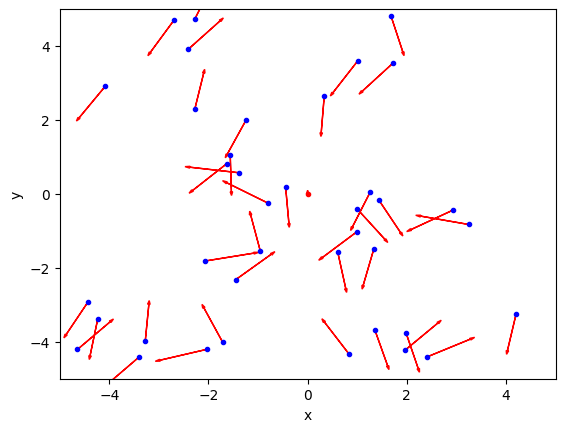

In [139]:
# Inspecteren van beginsituatie
plt.figure()

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)


for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
    plt.arrow(particle_object.r[0],particle_object.r[1], 
              particle_object.v[0],particle_object.v[1], 
              head_width=0.05, head_length=0.1, color='red')
plt.show()
#met de code in de comment wordt de richting en grootte van de snelheid van elk deeltje met een pijl weergegeven
#de pijlen beginnen op de positie van het deeltje en ze gaan in de richting van de totale snelheid
#de snelheid van elk deeltje is hetzelfde omdat bij de vorige vraag vy zo is aangemaakt:
#een y snelheid die positief of negatief is, en waarbij vy = sqrt(v_0^2-vx^2) oftewel vy^2+vx^2=v_0^2, dus de totale snelheid is altijd gelijk aan v_0

```{exercise} 
:label: ex-brownian-2

Er staat ook code met comments ervoor, wat doet deze code? 
Check je antwoord door de comments weg te halen.
Hoe wordt er voor gezorgd dat de snelheid van elk deeltje gelijk is?
```

```{solution} ex-brownian-2
Met de code in de comment wordt de richting en grootte van de snelheid van elk deeltje met een pijl weergegeven. De pijlen beginnen op de positie van het deeltje en ze gaan in de richting van de totale snelheid. De snelheid van elk deeltje is hetzelfde omdat bij de vorige vraag vy zo is aangemaakt:
Een y snelheid die positief of negatief is, en waarbij vy = sqrt(v_0^2-vx^2) oftewel vy^2+vx^2=v_0^2, dus de totale snelheid is altijd gelijk aan v_0
```

We gaan nu de functies van de simulatie weer aanroepen:

In [140]:
# Het bepalen of er een botsing plaats vindt
def collide_detection(self, other):
    dx = self.r[0] - other.r[0]
    dy = self.r[1] - other.r[1]
    rr = self.R + other.R
    return  dx**2+dy**2 < rr**2 
        
def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
    
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

def handle_collisions(particles):
#your code/answer
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    num_particles = len(particles)
    collisions = 0
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])
                collisions += 1
    return collisions
#your code/answer


In onderstaande code geven we de code voor de simulatie en volgen we de positie van het zware deeltje. 

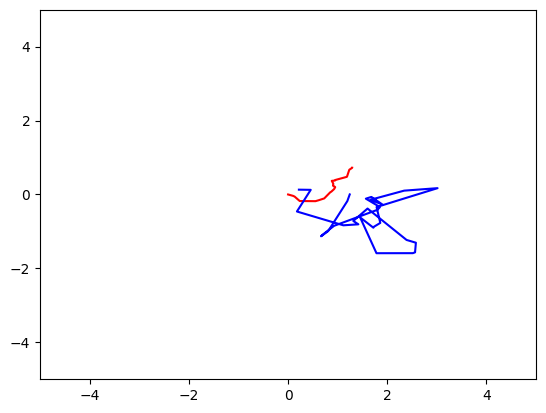

In [141]:
# tracken van het zware deeltje

track_x = []
track_y = []
track_x1 = []
track_y1 = []

#your code/answer

#your code/answer

#your code/answer
t = 400

for i in range(t+1):
#your code/answer
    
    for p in particles:
        p.update_position()    # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje
        
    handle_collisions(particles)

#your code/answer
    
    track_x.append(particles[N-1].r[0])
    track_y.append(particles[N-1].r[1])
    track_x1.append(particles[0].r[0])
    track_y1.append(particles[0].r[1])

#your code/answer

plt.figure()
plt.plot(track_x,track_y,'r')
plt.plot(track_x1,track_y1,'b')
plt.xlim(-Box_length, Box_length)
plt.ylim(-Box_length, Box_length)
plt.show()

#het lichte deeltje legt meestal meer afstand af, en die baan heeft scherpere hoeken omdat die meer door botsingen wordt beinvloed
#het valt me op hoe weinig ze in aanraking komen met elkaar (maar eens in de 20 keer dat ik het run)

```{exercise} Brownian motion in beeld
:label: ex-brownian-3
- Draai de onderstaande simulatie een keer en bestudeer de output.
- Voeg zelf een tweede tracking toe van een licht deeltje en verbeter de plot.
- Wat zijn overeenkomsten en verschillen tussen de beweging van de twee deeltjes?
- Wat valt je op als je de simulatie een aantal keer runt?
```

```{solution} ex-brownian-3
Het lichte deeltje legt meestal meer afstand af, en die baan heeft scherpere hoeken omdat die meer door botsingen wordt beinvloedt. Dat zorgt ook dat die vaak van richting verandert terwijl het grote deeltje vaak vrijwel in dezelfde richting blijft gaan. Het valt me op hoe weinig de twee geobserveerde deeltjes in aanraking komen met elkaar (maar eens in de 20 keer dat ik het run)
```

We zouden gevoel willen krijgen voor het aantal botsingen dat per tijdseenheid plaatsvindt. 
Elke keer dat er een botsing plaatsvindt, zou de counter met 1 omhoog moeten gaan.
Idealiter wordt het aantal botsingen opgeslagen in een array zodat je het aantal botsingen als functie van de tijd kunt weergeven.

```{exercise}
Pas bovenstaand idee toe in de eerder gemaakte code.
Plot hieronder het aantal botsingen als functie van de tijd.
```

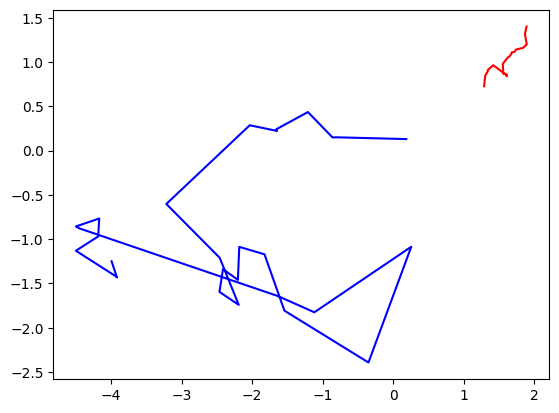

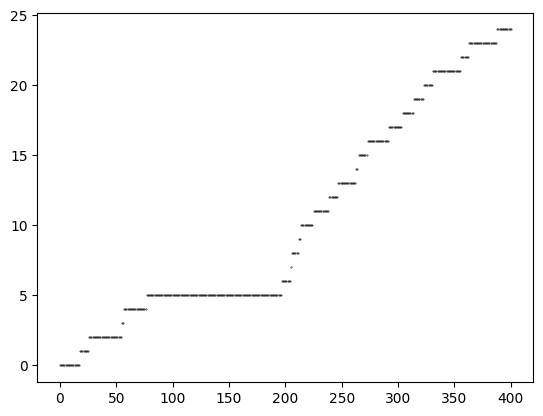

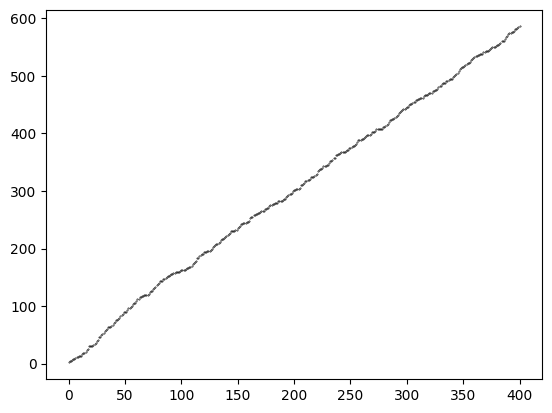

In [142]:
# tracken van het zware deeltje

track_x = []
track_y = []
track_x1 = []
track_y1 = []

t = 400
counter = np.zeros(t+1)
counter2 = np.zeros(t+1)

for i in range(t+1):
    
    for p in particles:
        p.update_position()    # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje
        
    handle_collisions(particles)

    for j in range(len(particles)-1):
        if collide_detection(particles[N-1], particles[j]):
            counter[i] += 1
    for j in range(len(particles)):
        for k in range(j+1,len(particles)):
            if collide_detection(particles[k], particles[j]):
                counter2[i] += 1
    
    track_x.append(particles[N-1].r[0])
    track_y.append(particles[N-1].r[1])
    track_x1.append(particles[0].r[0])
    track_y1.append(particles[0].r[1])

plt.figure()
plt.plot(track_x,track_y,'r')
plt.plot(track_x1,track_y1,'b')
plt.show()

sum = np.cumsum(counter)
sum2 = np.cumsum(counter2)

#aantal botsingen van het grote deeltje tegen t
plt.figure()
plt.plot(sum,'k.',markersize = 0.7)
plt.show()

#totaal aantal botsingen tegen t
plt.figure()
plt.plot(sum2,'k.',markersize = 0.7)
plt.show()

```{warning} 🌶 Let op!
:icon: false
De onderstaande opdrachten vallen buiten de stof maar tellen mee als je excellent wilt behalen.
```

In zulke fysica modellen is de afgelegde weg (afstand tussen begin en eindpunt) van belang.
Deze afgelegde weg zegt iets over de snelheid van difussie.
Idealiter bekijken we een histogram.
Maar voor een histogram hebben we veel deeltjes nodig.



```{exercise} Afgelegde weg 🌶
:label: ex-brownian-4

- Maak een simulatie met 361 deeltjes, waarvan 1 zwaar deeltje.
- Houd rekening met de boxgrootte, deze moet mee schalen!
- Maak een histogram van de afgelegde weg voor alle deeltjes. 
- Geef de afgelegde weg van het grote deeltje duidelijk aan.
```


In [143]:
#your code/answer


En nu we toch bezig zijn met twee verschillende deeltjes.... 

We kunnen twee "groepen" van deeltjes aanmaken, elk  met een andere massa. Als we dan de zwaartekracht aan zetten, dan zouden we verwachten dat de lichtere deeltjes boven komen "drijven".

```{exercise} Onderzoek dit vermoeden 🌶
- maak daartoe de box 2x zo hoog als breed
- verdubbel het totaal aantal deeltjes
- zet een artificieel grote zwaartekracht aan
```

In [144]:
#your code/answer
